### Baseline
Simple neural netowrk model composed of solely fully-connected (Dense) layers. Activated with functions of ReLU function for line and region segregation, and softmax function at the output later for multiple class classifciation problem.
### Baseline model training and validation achievement:
* Training accuracy: 62.92%
* Validation accuracy: 50.00%
### Baseline model test achievement:
|           | Precision | Recall | F1-Score | Support |
|-----------|-----------|--------|----------|---------|
| Happy     | 0.43      | 0.43   | 0.43     | 54      |
| Sad       | 0.43      | 0.49   | 0.46     | 47      |
| Angry     | 0.50      | 0.45   | 0.47     | 49      |
| other     |  0.49     |  0.42  | 0.50     | 49      |
| Accuracy  |           |        | 0.45     | 150     |
| Macro avg | 0.46      | 0.45   | 0.45     | 150     |
| Weighted avg | 0.46   | 0.45   | 0.45     | 150     |

### Dataset Analysis:
the dataset includes cat, dog and other species. additionally, an image may contains two species.
* we should first do face detection from line segments, to segments grouping in order to form a small region or part of the face, to forming an entire face by grouping based on the regions. in the following layer, the model should be able to identify if the face is one of cat, dog, or wild animals. in this part, there will be at least 3 layers given there will be at least one for line segments, at least one for segment grouping into region, and at least one for face forming based on regions. Here the activation functions should be ReLU.
* (we do not have such labels) If we have labels for speicies catgory, multi-label classification should be performed here. in this case, in certain step we shoudl identify if the picture contains cat, dog, and e.g. rabbit or no. so the here it should be binary classification for each unit(neuron). e.g. only two classes, cat and dog. output y = [ bool_has_cat, bool_has_dog ]. Hence this layer should be for instance using sigmoid as activation function.
* given that the chance of having that emotion category is approximated, now this follwoing layer should further learn classify the probablility of being an emotion category such that in the activation function should be Softmax having output neurons of three : probability of happy, probability of angry, and probability of sad.

In [2]:
# from google.colab import drive
# drive.mount('/content/drive')

In [51]:
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
import tensorflow as tf
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense, Flatten
from keras.optimizers import Adam
from keras.losses import CategoricalCrossentropy
from keras.metrics import CategoricalAccuracy
from keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import logging
logging.getLogger('tensorflow').setLevel
tf.autograph.set_verbosity(0)


In [52]:
# Function to load and preprocess images
def load_images_from_folder(folder):
    images = []
    for filename in os.listdir(folder):
        img = cv2.imread(os.path.join(folder, filename))
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            img = cv2.resize(img, (128, 128))  # Resize to a fixed size for the model
            images.append(img)
    return images

In [54]:
# Define the path to the dataset folders
happy_folder = "/content/drive/MyDrive/Pet_emothion_Recognition-main/pets_facial_expression_dataset/happy"
sad_folder = "/content/drive/MyDrive/Pet_emothion_Recognition-main/pets_facial_expression_dataset/Sad"
angry_folder = "/content/drive/MyDrive/Pet_emothion_Recognition-main/pets_facial_expression_dataset/Angry"
other_folder = "/content/drive/MyDrive/Pet_emothion_Recognition-main/pets_facial_expression_dataset/Other"

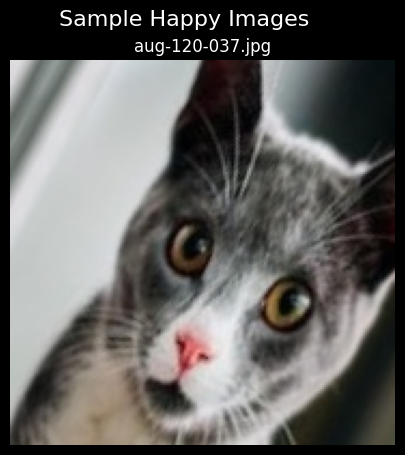

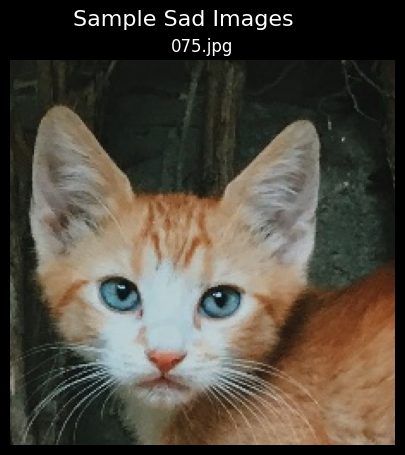

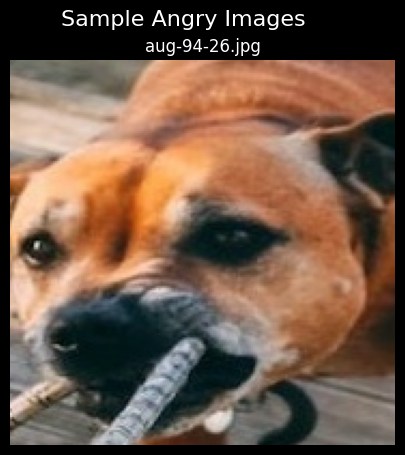

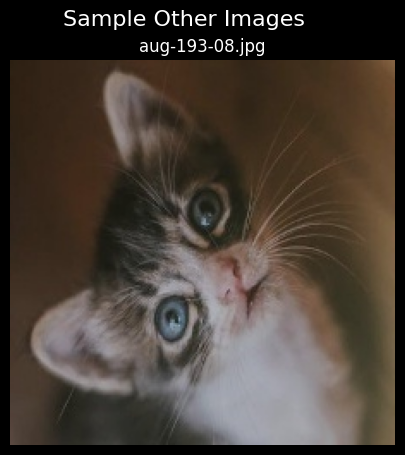

In [57]:
import os
import cv2
import matplotlib.pyplot as plt
import random

def display_sample_images(folder_path, emotion_label, num_images=1):
    image_files = [f for f in os.listdir(folder_path) if f.endswith(('.jpg', '.jpeg', '.png'))]
    sample_files = random.sample(image_files, min(num_images, len(image_files)))

    plt.figure(figsize=(15, 5))
    plt.suptitle(f'Sample {emotion_label} Images', fontsize=16)

    for i, filename in enumerate(sample_files):
        img_path = os.path.join(folder_path, filename)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Convert BGR to RGB for matplotlib

        plt.subplot(1, num_images, i + 1)
        plt.imshow(img)
        plt.title(filename)
        plt.axis('off')
    plt.show()

# Define the path to the dataset folders (assuming these are already defined in your notebook)
# happy_folder = "/content/drive/MyDrive/Pet_Facial_Expression_Recognition-main/pets_facial_expression_dataset/happy"
# sad_folder = "/content/drive/MyDrive/Pet_Facial_Expression_Recognition-main/pets_facial_expression_dataset/Sad"
# angry_folder = "/content/drive/MyDrive/Pet_Facial_Expression_Recognition-main/pets_facial_expression_dataset/Angry"

# Display sample images from each folder
display_sample_images(happy_folder, "Happy")
display_sample_images(sad_folder, "Sad")
display_sample_images(angry_folder, "Angry")
display_sample_images(other_folder, "Other")

### 1. Data pre-processing
* Since in the baseline model insteresed implementation should use conventional model, we'll stick with simple neural networks from draft for educational purposes, although it's important to note that this approach will possibily yield a very poor result for such a complex image processing task.
* First, you need to preprocess your images. This involves loading the images, resizing them to a uniform size, converting them to grayscale, and flattening them into vectors.

#### Benefits of Using Grayscale Images
Reduced Complexity: Grayscale images are less complex than color images, making them easier to process with simpler algorithms.
Reduced Computational Load: Grayscale images require less computational power and memory, as they have only one channel compared to three in color images.
Focus on Texture and Shape: Converting to grayscale can help the model focus on the texture and shape information, which might be more relevant for certain tasks like emotion detection in animals.

#### Load data and Combine data

In [59]:
happy_images = load_images_from_folder(happy_folder)
sad_images = load_images_from_folder(sad_folder)
angry_images = load_images_from_folder(angry_folder)
other_images = load_images_from_folder(other_folder)


# Create labels for each emotion category
happy_labels = [0] * len(happy_images)
sad_labels = [1] * len(sad_images)
angry_labels = [2] * len(angry_images)
other_labels = [3] * len(other_images)


# Concatenate images and labels
# X = np.array(happy_images + sad_images + angry_images + other_images)
# y = np.array(happy_labels + sad_labels + angry_labels + other_labels)

X = np.array(happy_images + sad_images + angry_images+other_images )
y = np.array(happy_labels + sad_labels + angry_labels+other_labels )

# Normalize pixel values to range [0, 1]
X = X.astype('float32') / 255.0

# One-hot encode the labels
y = to_categorical(y, 4)

In [61]:
print(X)
print(y)

[[[0.23921569 0.25490198 0.25490198 ... 0.1254902  0.11372549 0.11372549]
  [0.2509804  0.26666668 0.25882354 ... 0.11764706 0.10980392 0.10588235]
  [0.27058825 0.2784314  0.26666668 ... 0.11764706 0.10588235 0.10588235]
  ...
  [0.5019608  0.5019608  0.5019608  ... 0.02745098 0.03529412 0.04313726]
  [0.4745098  0.4745098  0.4745098  ... 0.08627451 0.05490196 0.03529412]
  [0.44313726 0.44313726 0.45490196 ... 0.07450981 0.0627451  0.03529412]]

 [[0.49019608 0.4745098  0.4627451  ... 0.48235294 0.48235294 0.5019608 ]
  [0.5137255  0.4862745  0.4745098  ... 0.4862745  0.49411765 0.5019608 ]
  [0.5137255  0.48235294 0.4745098  ... 0.49019608 0.4862745  0.49803922]
  ...
  [0.59607846 0.6431373  0.68235296 ... 0.45490196 0.4862745  0.5019608 ]
  [0.6627451  0.69803923 0.72156864 ... 0.49019608 0.4745098  0.5019608 ]
  [0.69411767 0.7137255  0.7372549  ... 0.5019608  0.5019608  0.47843137]]

 [[0.8627451  0.8666667  0.8666667  ... 0.05098039 0.05098039 0.05098039]
  [0.8666667  0.862745

In [62]:
import os
import cv2
import matplotlib.pyplot as plt
import random
from PIL import Image # Import Image from PIL

def show_sample_images(emotion_folders, samples_per_class=4):
    plt.figure(figsize=(samples_per_class * 4, len(emotion_folders) * 3.2))
    for i, (emotion, folder) in enumerate(emotion_folders.items()):
        files = [f for f in os.listdir(folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        sample_files = np.random.choice(files, min(samples_per_class, len(files)), replace=False)

        for j, filename in enumerate(sample_files):
            img_path = os.path.join(folder, filename)
            img = Image.open(img_path).convert('RGB')
            plt.subplot(len(emotion_folders), samples_per_class, i*samples_per_class + j + 1)
            plt.imshow(img)
            plt.axis('off')
            if j == 0:
                plt.ylabel(emotion, fontsize=14, rotation=0, labelpad=50)
            if i == 0:
                plt.title(filename[:15] + '...' if len(filename) > 15 else filename)
    plt.suptitle("Sample Pet Facial Images per Emotion Class", fontsize=16, y=0.95)
    plt.tight_layout()
    plt.show()

# Define the emotion_folders dictionary
emotion_folders = {
    "Happy": happy_folder,
    "Sad": sad_folder,
    "Angry": angry_folder,
    "Other": other_folder
}

show_sample_images(emotion_folders)

Output hidden; open in https://colab.research.google.com to view.

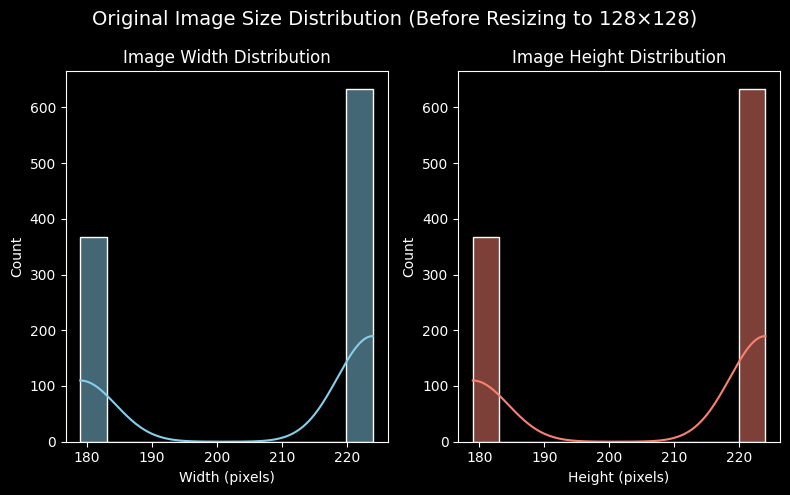

Average image size: 207 × 207
Min size: 179×179 | Max size: 224×224


In [63]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

widths, heights = [], []
for emotion, folder in emotion_folders.items():
    for filename in os.listdir(folder):
        if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
            img = cv2.imread(os.path.join(folder, filename))
            if img is not None:
                h, w = img.shape[:2]
                widths.append(w)
                heights.append(h)

# ── Black background style ──────────────────────────────────────────
plt.style.use('dark_background')

fig, axes = plt.subplots(1, 2, figsize=(8, 5))
fig.patch.set_facecolor('black')

# Width Distribution
axes[0].set_facecolor('black')
sns.histplot(widths, kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('Image Width Distribution', color='white')
axes[0].set_xlabel('Width (pixels)', color='white')
axes[0].tick_params(colors='white')
axes[0].spines[:].set_color('white')

# Height Distribution
axes[1].set_facecolor('black')
sns.histplot(heights, kde=True, color='salmon', ax=axes[1])
axes[1].set_title('Image Height Distribution', color='white')
axes[1].set_xlabel('Height (pixels)', color='white')
axes[1].tick_params(colors='white')
axes[1].spines[:].set_color('white')

fig.suptitle('Original Image Size Distribution (Before Resizing to 128×128)',
             fontsize=14, color='white')
plt.tight_layout()
plt.show()
# ────────────────────────────────────────────────────────────────────

print(f"Average image size: {np.mean(widths):.0f} × {np.mean(heights):.0f}")
print(f"Min size: {min(widths)}×{min(heights)} | Max size: {max(widths)}×{max(heights)}")

### 3. Splitting the Data
Split dataset into training and testing sets. This is essential for evaluating the performance of the model.
A common split is 80% for training and 20% for testing.

In [64]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

In [65]:
# Build the simple neural netowrk model
# note: no sigmoid layers, four layers, and dropout layers 0.1, learning rate 0.000001 epoch 200 gives Training accuracy: 61.67% Validation accuracy: 51.67%
# Define the model
emotion_model = Sequential([
    Flatten(input_shape=(128, 128)),
    Dense(256, activation='relu', name="l1"),
    Dropout(0.1),  # Dropout layer after first Dense layer
    Dense(1024, activation='relu', name="l2"),
    Dropout(0.1),  # Dropout layer after second Dense layer
    Dense(50, activation='relu', name="l3"),
    Dropout(0.1),  # Dropout layer after third Dense layer
    Dense(4, activation='softmax', name="l4")  # Output layer for 4 classes with softmax activation
])

emotion_model.summary()

# Compile the model
emotion_model.compile(
    loss=CategoricalCrossentropy(from_logits=False),
    optimizer=Adam(learning_rate=0.000001),
    metrics=[CategoricalAccuracy()]
)



/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ l1 (Dense)                      │ (None, 256)            │     4,194,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ l2 (Dense)                      │ (None, 1024)           │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ l3 (Dense)                      │ (None, 50)             │        51,250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ l4 (Dense)                      │ (None, 4)              │           204 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,509,182 (17.20 MB)

 Trainable params: 4,509,182 (17.20 MB)

 Non-trainable params: 0 (0.00 B)

We can examine details of the model by first extracting the layers with `model.layers` and then extracting the weights with `layerx.get_weights()` as shown below.

### 6. Train the NN

In [66]:
# Define early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10)
# Train the model
history = emotion_model.fit(X_train, y_train, epochs=200, validation_split=0.2, callbacks=[early_stopping])


# For training accuracy and loss
training_accuracy = history.history['categorical_accuracy']
training_loss = history.history['loss']

# For validation accuracy and loss
validation_accuracy = history.history['val_categorical_accuracy']
validation_loss = history.history['val_loss']

# print the training and validation accuracy percentage
print(f"Training accuracy: {training_accuracy[-1]*100:.2f}%")
print(f"Validation accuracy: {validation_accuracy[-1]*100:.2f}%")

Epoch 1/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - categorical_accuracy: 0.2625 - loss: 1.4127 - val_categorical_accuracy: 0.2500 - val_loss: 1.3866
Epoch 2/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - categorical_accuracy: 0.2672 - loss: 1.3927 - val_categorical_accuracy: 0.2562 - val_loss: 1.3829
Epoch 3/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - categorical_accuracy: 0.2672 - loss: 1.3895 - val_categorical_accuracy: 0.2875 - val_loss: 1.3802
Epoch 4/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - categorical_accuracy: 0.2750 - loss: 1.3842 - val_categorical_accuracy: 0.2812 - val_loss: 1.3812
Epoch 5/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - categorical_accuracy: 0.2922 - loss: 1.3857 - val_categorical_accuracy: 0.2875 - val_loss: 1.3813
Epoch 6/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - categorical_accuracy: 0.2688 - loss: 1.3880 - val_categorical_accuracy: 0.2750 - val_loss: 1.3796
Epoch 7/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - categorical_accuracy: 0.2922 - loss: 1.3

### 7. Evaluate

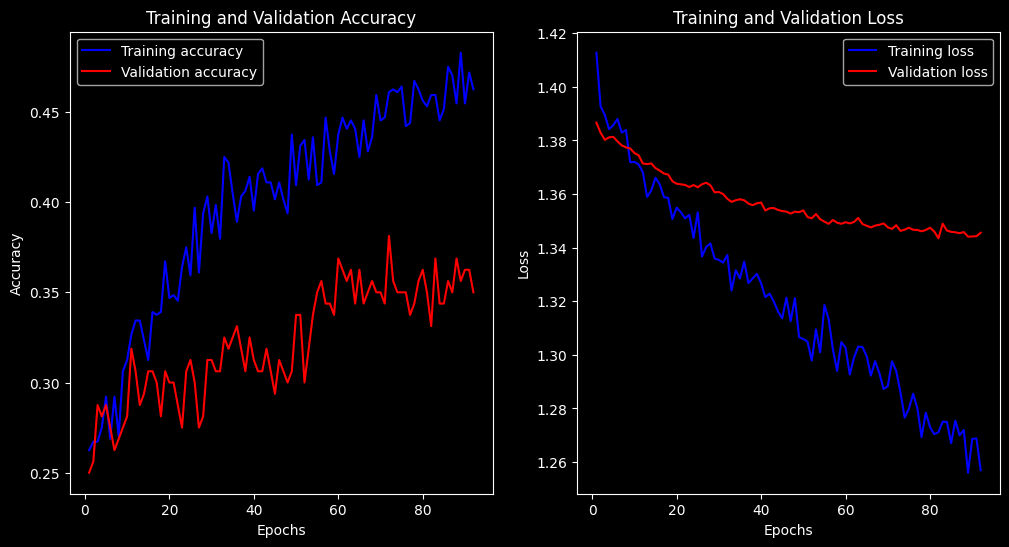

In [67]:
# # Predict on test data
import matplotlib.pyplot as plt

# Get the actual number of epochs model was trained for
n_epochs = len(training_accuracy)

epochs = range(1, n_epochs+1)

# Plot training and validation accuracy
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs, training_accuracy, 'b-', label='Training accuracy')
plt.plot(epochs, validation_accuracy, 'r-', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot training and validation loss
plt.subplot(1, 2, 2)
plt.plot(epochs, training_loss, 'b-', label='Training loss')
plt.plot(epochs, validation_loss, 'r-', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step


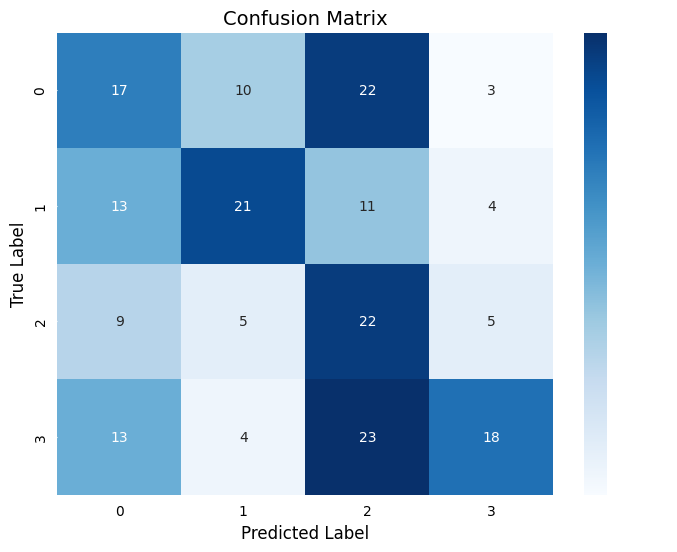


Classification Report:
              precision    recall  f1-score   support

           0       0.33      0.33      0.33        52
           1       0.53      0.43      0.47        49
           2       0.28      0.54      0.37        41
           3       0.60      0.31      0.41        58

    accuracy                           0.39       200
   macro avg       0.43      0.40      0.39       200
weighted avg       0.45      0.39      0.40       200



In [68]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Make predictions on test data
y_pred = emotion_model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Set white background for the entire figure
plt.figure(figsize=(8, 6), facecolor='white')

# Use a light colormap for the heatmap
sns.heatmap(cm, annot=True, fmt='d',

            cmap='Blues',
            xticklabels=range(cm.shape[0]),
            yticklabels=range(cm.shape[1]),
            cbar_kws={'label': 'Count'})

# Set title and labels with dark text
plt.title('Confusion Matrix', fontsize=14, color='black')
plt.ylabel('True Label', fontsize=12, color='black')
plt.xlabel('Predicted Label', fontsize=12, color='black')

# Change tick colors to black
plt.xticks(color='black')
plt.yticks(color='black')

# Save with white background
plt.savefig('confusion_matrix_light.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# Print classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred_classes))

# New Section

In [15]:
emotion_model.save('/content/drive/MyDrive/Pet_Facial_Expression_Recognition-main/base_facial_emotion_model.h5')

#### Visualizing Test Angry

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 428ms/step
Predicted Emotion: sad
Confidence [happy, sad, angry]: [0.30455416 0.4614842  0.23396155]


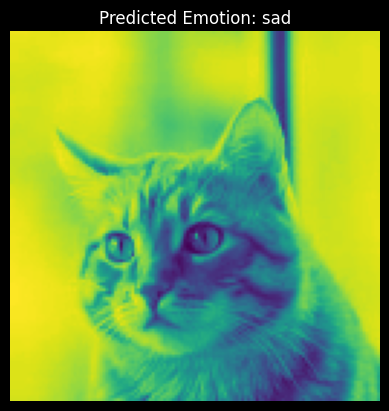

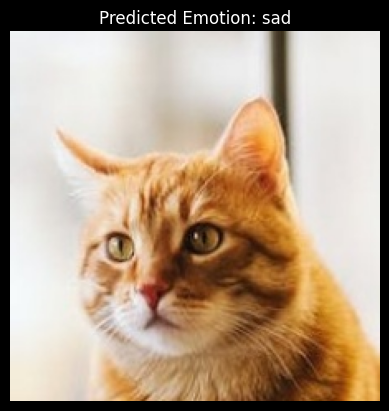

In [16]:
from keras.models import load_model
# Load the saved model
loaded_model = load_model("/content/drive/MyDrive/Pet_emothion_Recognition-main/base_facial_emotion_model.h5")

# Load a custom test image
custom_test_image_path = "/content/drive/MyDrive/Pet_emothion_Recognition-main/pets_facial_expression_dataset/Angry/06.jpg"

custom_test_image = cv2.imread(custom_test_image_path)
custom_test_image = cv2.cvtColor(custom_test_image, cv2.COLOR_BGR2GRAY)
custom_test_image = cv2.resize(custom_test_image, (128, 128))
custom_test_image = custom_test_image.astype('float32') / 255.0

# Reshape the image to match the model input shape
custom_test_image = np.expand_dims(custom_test_image, axis=0)
custom_test_image = np.expand_dims(custom_test_image, axis=-1)

# Make predictions on the custom test image
prediction = loaded_model.predict(custom_test_image)
prediction_prob = prediction[0]

emotion_label = np.argmax(prediction[0])

# Map the predicted label to emotion class
emotion_classes = {0: 'happy', 1: 'sad', 2: 'angry'}
predicted_emotion = emotion_classes[emotion_label]

# Print the custom test image and its predicted label
print(f"Predicted Emotion: {predicted_emotion}")
print(f"Confidence [happy, sad, angry]: {prediction_prob}")

import matplotlib.pyplot as plt

#Display the custom test image using matplotlib
plt.imshow(custom_test_image[0, :, :, 0])
plt.title(f"Predicted Emotion: {predicted_emotion}")
plt.axis('off')  # Hide axes
plt.show()

from PIL import Image
# Display the original custom test image using PIL
img_pil = Image.open(custom_test_image_path)
plt.imshow(np.array(img_pil))
plt.title(f"Predicted Emotion: {predicted_emotion}")
plt.axis('off')  # Hide axes
plt.show()

## Limitations
* Feature Extraction: This approach uses very basic feature extraction (flattening the image), which might not capture the necessary details for accurate emotion classification.
* Model Complexity: Logistic regression is quite basic for image classification tasks.
* Data Quality: The quality and size of your dataset will significantly impact the performance of your model.